In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  #so that we can interact with our graghts and see the values
from sklearn.model_selection import train_test_split  #to split data
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression   #The model we want to use
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display #so that we can print the table more beautiful.(DataFrame)
#Instead of "print" we now use "display"


sales_data = pd.read_csv(r"C:\Users\HP\Desktop\CODE ALPHA\archive 2\Advertising.csv")
display(sales_data)
display(sales_data.info())
display(sales_data.describe())
salesdrop = sales_data.dropna()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


None

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [20]:
import pandas as pd
# Make index start from 1
sales_data.index = range(1, len(sales_data) + 1)
#drops a colomn "unnamed: 0"
sales_data.drop(columns=['Unnamed: 0'], inplace=True)
display(sales_data)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


LOOKS BETTER NOW <br>

The table shows advertising spend across three media channels — TV, Radio, and Newspaper — and the<br> resulting Sales.<br>

The goal is to use these inputs to predict future sales based on how much is spent on each channel.

What we are going to do next <br>

1. Clean and prepare the data (check for missing values, normalize if needed).<br>

2. Split into training and testing sets. <br>

3. Train a regression model (e.g., LinearRegression from scikit-learn). <br>

4. Evaluate using RMSE or R² to see how well your model predicts sales. <br>

5. Interpret coefficients — they’ll tell you how much each advertising channel impacts sales. <br>

IN THIS CASE, OUR TARGET COLUMN IS THE "Sale"

In [22]:
sales_plot = px.histogram(sales_data, x = 'Sales', marginal = 'box', title = 'Sales', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) #only thing that can be used to put a gap)
sales_plot.show()

In [21]:
sales_plot = px.histogram(sales_data,x= 'TV' , y = 'Sales', marginal = 'box', title = 'Sales', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) #only thing that can be used to put a gap)
sales_plot.show()  #shows that cars of latest years cost more.

In [23]:
sales_data.Sales.corr(sales_data.TV)

np.float64(0.7822244248616066)

In [24]:
sales_plot = px.histogram(sales_data,x= 'Newspaper' , y = 'Sales', marginal = 'box', title = 'Sales', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) 
sales_plot.show() 

In [38]:
print('Newspaper =',sales_data.Sales.corr(sales_data.Newspaper))
print('Radio =', sales_data.Sales.corr(sales_data.Radio))
print('TV =', sales_data.Sales.corr(sales_data.TV))

sales_data[['Radio_log','TV_log','Newspaper_log']] = np.log1p(sales_data[['Radio','TV','Newspaper']])

print('Radio log =', sales_data.Sales.corr(sales_data.Radio_log))   

print('TV log =', sales_data.Sales.corr(sales_data.TV_log))

print('Newspaper log =', sales_data.Sales.corr(sales_data.Newspaper_log))

display(sales_data)

Newspaper = 0.22829902637616534
Radio = 0.5762225745710552
TV = 0.7822244248616066
Radio log = 0.5359863183188297
TV log = 0.758453357424465
Newspaper log = 0.16450123601881136


,TV,Radio,Newspaper,Sales,Radio_log,TV_log,Newspaper_log,radio_scaler
1,230.1,37.8,69.2,22.1,3.658420,5.442851,4.251348,0.981522
2,44.5,39.3,45.1,10.4,3.696351,3.817712,3.830813,1.082808
3,17.2,45.9,69.3,9.3,3.848018,2.901422,4.252772,1.528463
4,151.5,41.3,58.5,18.5,3.744787,5.027165,4.085976,1.217855
5,180.8,10.8,58.4,12.9,2.468100,5.202907,4.084294,-0.841614
...,...,...,...,...,...,...,...,...
196,38.2,3.7,13.8,7.6,1.547563,3.668677,2.694627,-1.321031
197,94.2,4.9,8.1,9.7,1.774952,4.555980,2.208274,-1.240003
198,177.0,9.3,6.4,12.8,2.332144,5.181784,2.001480,-0.942899
199,283.6,42.0,66.2,25.5,3.761200,5.651085,4.207673,1.265121


In [29]:
sales_plot = px.histogram(sales_data,x= 'Radio' , y = 'Sales', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) 
sales_plot.show() 

In [ ]:
sales_plot = px.histogram(sales_data,x= 'Newspaper_log' , y = 'Sales', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) 
sales_plot.show()

#change the valies of 'x' to see the shapes of each log transformation.

We can see that Cars with lower mileage, has higher prices

In [36]:
display(sales_data)

,TV,Radio,Newspaper,Sales,Radio_log,TV_log,Newspaper_log,radio_scaler
1,230.1,37.8,69.2,22.1,3.658420,5.442851,4.251348,0.981522
2,44.5,39.3,45.1,10.4,3.696351,3.817712,3.830813,1.082808
3,17.2,45.9,69.3,9.3,3.848018,2.901422,4.252772,1.528463
4,151.5,41.3,58.5,18.5,3.744787,5.027165,4.085976,1.217855
5,180.8,10.8,58.4,12.9,2.468100,5.202907,4.084294,-0.841614
...,...,...,...,...,...,...,...,...
196,38.2,3.7,13.8,7.6,1.547563,3.668677,2.694627,-1.321031
197,94.2,4.9,8.1,9.7,1.774952,4.555980,2.208274,-1.240003
198,177.0,9.3,6.4,12.8,2.332144,5.181784,2.001480,-0.942899
199,283.6,42.0,66.2,25.5,3.761200,5.651085,4.207673,1.265121


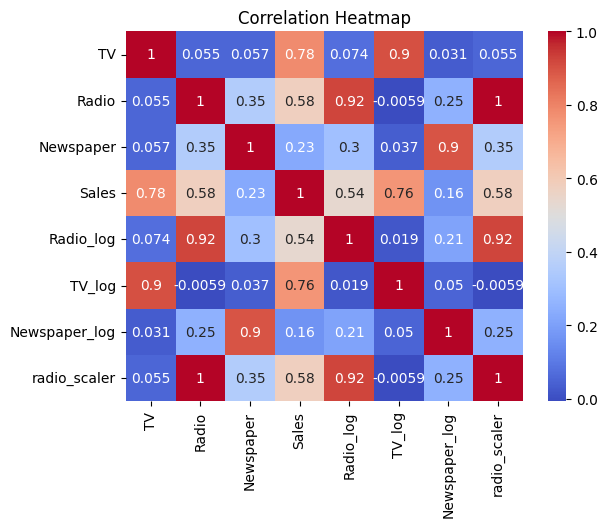

In [39]:
sns.heatmap(sales_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Because machine learning models are bad at handling extreme gaps in numbers.**

Think of it this way — imagine you're teaching a student to spot patterns in these numbers:

```
1,000
5,000
10,000
500,000  ← this one number dominates everything
```

The student's eyes keep getting drawn to `500,000` and ignoring the rest. That's exactly what happens to a model — it gets **distracted by the big numbers** and struggles to learn from the smaller ones.

After log transform:
```
6.9
8.5
9.2
13.1  ← no longer screaming for attention
```

Now all values are in a **similar range** and the model can learn from all of them fairly.

**In practical terms for your car data:**

- Without log → the model thinks a car that drove `500k km` is incomparably different from one that drove `50k km`
- With log → the model understands it as just a **proportional difference**, which reflects reality better

**The 3 main reasons to do it:**

1. **Fairness** — no single value dominates the learning
2. **Better predictions** — model sees patterns more clearly
3. **Lower RMSE** — your error score improves because predictions are more accurate

It's essentially **translating your data into a language the model understands better.**

In [43]:
px.scatter(sales_data, y = 'Sales', x = 'TV')

MODEL RECOMMENDATION
Begin with Linear Regression for baseline. Y = MX + C (equation of a straigh line)

Then test RANDOM FOREST and XGBOOST
they usually outperform linear models for car price prediction.

Evaluate using R², MAE, and RMSE to compare.

<2> If Nonlinear Patterns Exist (as your plot suggests)
Try nonlinear or ensemble models that handle complex relationships:

Polynomial Regression (adds squared or cubic terms)

Random Forest Regressor — captures nonlinear interactions automatically.

XGBoost or LightGBM — excellent for tabular data with mixed feature types.

Gradient Boosting Regressor — balances bias and variance well.

So we will use 

Selling Price = M x drivenKm_Age + c

In [68]:
def est_price (estprice, m, c ):   #def is used to define our model
    return m*estprice + c 
m = 0.1
c = 5           #this is our first model formular (but it also what LinearRegression does)
estprice = sales_data['TV']       #we now use our desires column here
estimated_price = est_price(estprice, m,c)
display(estimated_price)
    

1      28.01
2       9.45
3       6.72
4      20.15
5      23.08
       ...  
196     8.82
197    14.42
198    22.70
199    33.36
200    28.21
Name: TV, Length: 200, dtype: float64

CheckPoint

In [45]:
display(sales_data['Sales']) #juat to compare with the actual selling price

1      22.1
2      10.4
3       9.3
4      18.5
5      12.9
       ... 
196     7.6
197     9.7
198    12.8
199    25.5
200    13.4
Name: Sales, Length: 200, dtype: float64

In [52]:
px.scatter(sales_data, y = estimated_price, x = 'TV')  #they have a linear relationship.

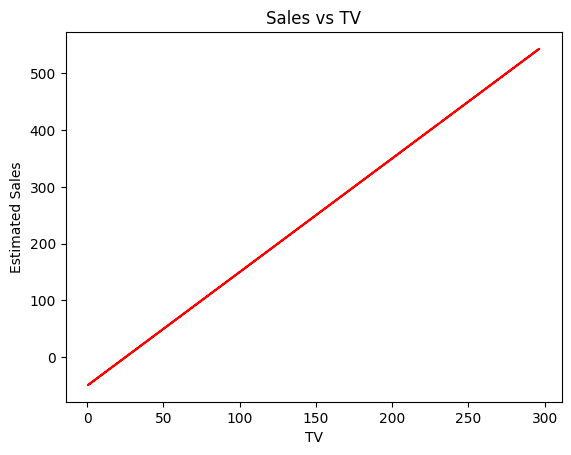

In [53]:
import matplotlib.pyplot as plt

# Assuming you already have these columns in your DataFrame
x = sales_data['TV']      # numeric column
y = estimated_price                  # predicted or target values

plt.plot(x, y, 'r-')   
px.scatter(sales_data, y = 'Sales', x = 'TV')
plt.xlabel('TV')
plt.ylabel('Estimated Sales')
plt.title('Sales vs TV')
plt.show()


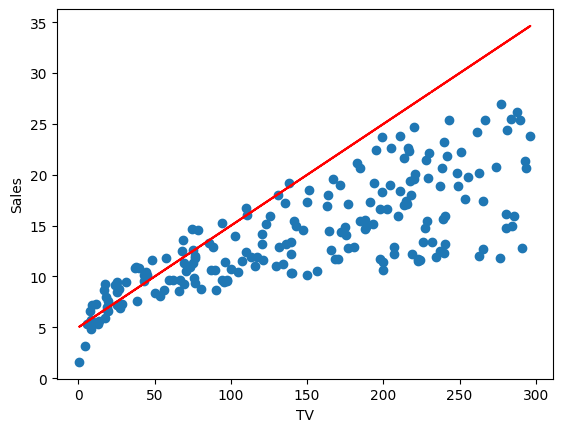

In [69]:
#target = pd.DataFrame(cars['Selling_Price']) #this is how to convert a single column to a dataframe and work with it
plt.plot(sales_data['TV'], estimated_price , 'r-')
plt.scatter(sales_data['TV'], sales_data['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

LETS GET A FUNCTION THAT WE CAN USE TO TRY DIFFERENT VALUES OF 'M' AND 'C'

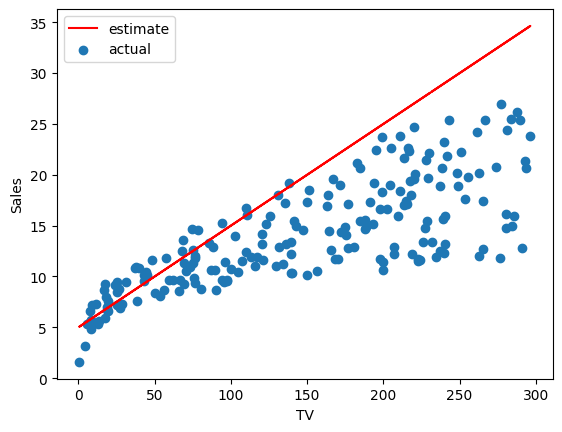

,Predicted,Actual
1,28.01,22.1
2,9.45,10.4
3,6.72,9.3
4,20.15,18.5
5,23.08,12.9
...,...,...
196,8.82,7.6
197,14.42,9.7
198,22.70,12.8
199,33.36,25.5


In [70]:
estprice = sales_data['TV']

#you can use this function to manually try and fit the line of regression

def try_price(m, c):
    def est_price(estprice, m, c):
        return m * estprice + c

    estimated_price = est_price(estprice, m, c)

    plt.plot(sales_data['TV'], estimated_price, 'r-')
    plt.scatter(sales_data['TV'], sales_data['Sales'])
    plt.xlabel('TV')
    plt.ylabel('Sales')
    plt.legend(['estimate', 'actual'])
    plt.show()
    return estimated_price
target = sales_data['Sales']
comparison = try_price(0.1,5)   #change the values of try(2,1) to see how close you get to the actual price
forecast = pd.DataFrame({'Predicted': comparison, 'Actual': target}) #The fix is to build the DataFrame from a dict mapping column names to your two series. 
display(forecast)
 

CALCULATE LOSS/COST FUNCTIONS

We will now compare our estimate with the actual selling price using the Root Mean Square Error (RMSE)

RMSE (Root Mean Square Error) is used to measure how far off your model's predictions are from the actual values.
Absolut values '|predicted - actual|' can be takes too.
NOTE that Outliers have a bigger effect on Square method more than Abosolute Methods because if the gap is too much, the square will also be bigger. However, absolute values just ignores the -ve sign. 

E.g.  (4- 9) gives -5. Which means the Square is 25. But Abosolute value just leave it at 5

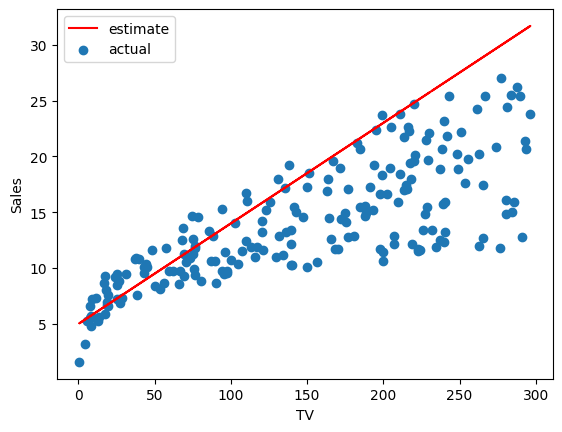

np.float64(6.439898197564927)

In [75]:
target = sales_data['Sales']
predictions = try_price(0.09,5)   #from the 'rmse result' (1,2) is better than (2,1)
def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))


rmse (target, predictions)

your `m` value can be very small to compensate. Here's why:

**Your formula is:**
```
estimated_price = m * estprice + c
```

If `estprice` is `1000+` and you want output between `3-20`, then `m` needs to be tiny to scale it down, for example:

```
m = 0.001, c = 2
→ 0.001 * 1000 + 2 = 3      ✅
→ 0.001 * 5000 + 2 = 7      ✅
→ 0.001 * 18000 + 2 = 20    ✅
```

**The real problem though** is that finding the right `m` by trial and error becomes very hard because:
- A tiny change in `m` (e.g. `0.001` → `0.002`) causes a huge swing in predictions
- It makes tuning very frustrating

**The proper fix is to scale your feature first:**

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
estprice = scaler.fit_transform(cars[['Car_depre_price']])  # squishes values to 0-1 range
```

Now your feature is between `0` and `1`, so your `m` and `c` values become much more intuitive to tune and your predictions in the `3-20` range are easier to dial in.

**In short:**
- Mathematically it still works ✅
- But practically, scaling your feature first makes life much easier ✅

In [77]:
model = LinearRegression()   #this is where you define what kind of model you want and what the relationship is

In [79]:
fstinput = sales_data[['TV']]  #cars[] will give me 1D, remember that 'mosel.fit' need 2D so use cars[[]]
target = sales_data['Sales'] #this one can be left as 1D
display(fstinput.shape, target.shape)


(200, 1)

(200,)

Now we will split our data, some for training it to know how good it is and some for testing it before deploying

In [105]:
from sklearn.model_selection import train_test_split

# Select multiple columns as features
x = sales_data[['TV','Radio', 'Newspaper']]   # independent variables    
y = sales_data['Sales']                        # target variable

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


This called tuple unpacking. It’s Python’s way of assigning multiple outputs from a function in one clean line. <br> 
because train_test_split runs and returns a tuple with four elements: <br>

Element 0 → training features (X_train) <br>

Element 1 → testing features (X_test)<br>

Element 2 → training target (y_train)<br>

Element 3 → testing target (y_test)<br>

(X_train_array, X_test_array, y_train_array, y_test_array)

Tuple unpacking happens:
Python sees four variables on the left side, separated by commas.
It matches them in order:

X_train = tuple[0]

X_test = tuple[1]

y_train = tuple[2]

y_test = tuple[3]

So the number of returned elements depends on how many arrays you feed in. Each one gets split into a train part and a test part


train_test_split() divides your data into training and testing subsets. <br>

fstinput → your features (independent variables). <br>

target → your labels (dependent variable). <br>

test_size=0.2 → 20 % of the data goes to testing, 80 % to training. <br>

random_state=42 → ensures the split is reproducible every time you run it. <br>

In [106]:
model = LinearRegression()
model.fit(x_train, y_train)   

#we could have also said LinearRegression.fit(), but we already assinged model= LinearRegression()
#'fit' here will help us determine the best slope 'm' and y-intercept'c' of out regression line.
#it will continue to do all those (2,1) changing and calculate RMSE and give me the result

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The .fit() method is the moment your model “learns” from the data.

So, now we can predict the prices for any car if we know its 

THIS IS BASICALLY THE PRICTION USER INTERFACE <br>
Because it allows you predict the price of any car, given the "year","mileage" and "the type of seller (dealer/owner)"

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


# Predict using your trained model
prediction = model.predict(x_test)   #now testing with the data i split to test only

# Combine actual and predicted into a DataFrame
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,    #convert them to Dictionaries a basic way to generating a DataFrame
    "Predicted Sales": prediction     #Our Model Predictions
})

display(comparison)  #expect 40 rows, cus i rained it with 40 rows

def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))


print('RMSE = ', rmse(y_test, prediction))
Coefficient_of_determination = r2_score(y_test, prediction)

print("Coefficient_of_determination =", Coefficient_of_determination)


,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


RMSE =  1.78159966153345
Coefficient_of_determination = 0.899438024100912


Why this works <br>
y_test.values → converts your actual sales into a NumPy array. <br>

predictions → already a NumPy array from .predict().<br>

pd.DataFrame → aligns them neatly into columns.<br>

 Coefficient_of_determination (R²) tells you how much of the variation in your target (Sales) can be explained by your features (TV, Radio, Newspaper). <br>

It’s a number between 0 and 1 (sometimes negative if the model is really poor).<br>

A high R² means your features are good predictors of the target.<br>

A low R² means your model isn’t capturing much — maybe you need more features or a different type of model.<br>

If your regression model predicting sales from TV, Radio, and Newspaper spends gives R² = 0.85, it means:<br>

85% of the variation in sales is explained by your advertising spend.<br>

The remaining 15% is due to other factors not captured in the model (e.g., market conditions, product quality, seasonality).<br>

USE INTERFACE

In [121]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Collect user input
TV_price = float(input("Enter the amount paid for TV subscription: "))
Radio_price = float(input("Enter the amount paid for Radio subscription: "))
Newspaper_price = float(input("Enter the amount paid for Newspaper subscription: "))

inputsdata = np.array([[TV_price,Radio_price,Newspaper_price]])

# Predict using your trained model
prediction = model.predict(inputsdata)
print("Predicted value:", prediction)


Predicted value: [20.61397147]


c:\Users\HP\Desktop\VS CODE FOLDERS\test environment.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [84]:
display(sales_data)

,TV,Radio,Newspaper,Sales,Radio_log,TV_log,Newspaper_log,radio_scaler
1,230.1,37.8,69.2,22.1,3.658420,5.442851,4.251348,0.981522
2,44.5,39.3,45.1,10.4,3.696351,3.817712,3.830813,1.082808
3,17.2,45.9,69.3,9.3,3.848018,2.901422,4.252772,1.528463
4,151.5,41.3,58.5,18.5,3.744787,5.027165,4.085976,1.217855
5,180.8,10.8,58.4,12.9,2.468100,5.202907,4.084294,-0.841614
...,...,...,...,...,...,...,...,...
196,38.2,3.7,13.8,7.6,1.547563,3.668677,2.694627,-1.321031
197,94.2,4.9,8.1,9.7,1.774952,4.555980,2.208274,-1.240003
198,177.0,9.3,6.4,12.8,2.332144,5.181784,2.001480,-0.942899
199,283.6,42.0,66.2,25.5,3.761200,5.651085,4.207673,1.265121


In [122]:
model.intercept_

np.float64(2.979067338122629)

scikit‑learn’s `LinearRegression()` implements the classic linear model, which in its simplest form is the familiar equation:

\[
y = m x + c
\]

where:
- \(y\) = predicted output (target variable)  
- \(x\) = input feature (independent variable)  
- \(m\) = slope (coefficient)  
- \(c\) = intercept (bias term)

---

### But here’s the important detail:
- If you have **one feature**, it’s literally \(y = m x + c\).  
- If you have **multiple features**, it generalizes to:

\[
y = x0+ Kx_1 + Kx_2 + ... + Kx_n
\]

where \(x0) is the intercept and each \(\Xn\) is a coefficient for feature \(K).


👉 In practice, after fitting your model with `model.fit(X, y)`, you can inspect the learned parameters:

```python
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
```

That will show you the actual \(c\) and \(m\) values (or multiple slopes if you have more than one feature).

---

Would you like me to show you how to **interpret those coefficients** in the context of your car dataset — e.g., how much the price changes per unit increase in mileage or seller type?

In [123]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [0.04472952 0.18919505 0.00276111]
Intercept: 2.979067338122629


So -1 is just a shortcut that adapts to whatever length your array has. If tomorrow you had 100 <br> predictions, reshape(-1, 1) would give (100, 1) without you needing to change the code.<br>

Why not just 1?<br>
If you wrote reshape(1, 1), NumPy would force the array into exactly 1 row and 1 column, which only <br>
works if your array has exactly 1 element. For 50 elements, it would throw an error because the <br>sizes don’t match.

*Stopped here

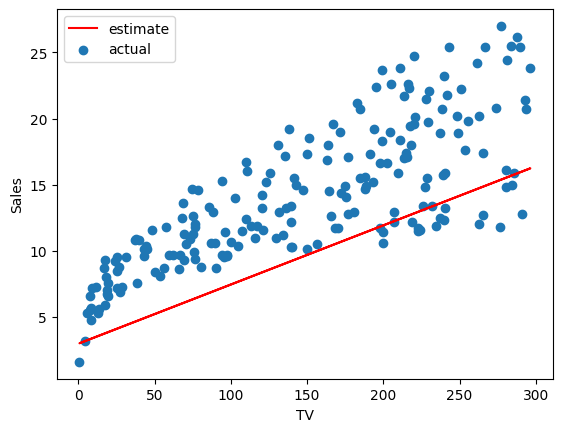

np.float64(5.524329027706898)

In [127]:
target = sales_data['Sales']
try_predict = try_price(0.04472952 ,2.979067338122629)   #we can now try the values our model used and also visualize the line
def rmse (target, try_predict):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - try_predict)))


rmse (target, try_predict)

But here’s the important detail:
If you have one feature, it’s literally 
𝑦 = 𝑚𝑥 + 𝑐 . <br>
If you have multiple features, it generalizes to:<br>

𝑦 = c + 𝛽b + 𝛽c + ⋯ + 𝛽𝑛
where 
c is the intercept and each 

𝛽
 is a coefficient for feature 
n
So in your car price model, if you’re using two features (like car_usage and seller_type), the formula looks like:

Price = c + 𝛽⋅car_usage + 𝛽⋅seller_type

SUMMARY <BR>
Training = model.fit(X, y) → learns from your dataset.   X = cars[['car_useage', 'Fuel_Type']]<br>

Prediction = model.predict(new_data) → uses what it learned to estimate new outcomes.

In [ ]:
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,...,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,Driven_kms_log,car_useage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,...,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592,10.203629,0.850302
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,...,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955,10.668979,0.820691
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,...,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277,8.839422,0.982158
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,...,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414,8.556606,0.570440
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,...,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082,10.656106,0.888009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,...,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763,10.433792,1.043379
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,...,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100,11.002117,1.000192
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,...,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342,11.384353,0.669668
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,...,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980,9.105091,1.011677


check point

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from datetime import datetime

features = cars[['car_useage', 'Diesel', 'Individual','Dealer','Manual','Automatic','Car_Age']]  #Added one more Feature
#That’s 7 columns. So, during prediction, you must supply all 7 values in the same order.
target = cars['Selling_Price'] 


model = LinearRegression() 
model.fit(features, target)  #(x,y) trains the model with the selected features.

# Collect user input
driven_kms = float(input("Enter the mileage of your car: "))
year = int(input("Enter the year your car was manufactured: "))

# Fuel type
fuel_type = input("Enter fuel type (Diesel/Petrol): ").strip().lower()
diesel = 1 if fuel_type == "diesel" else 0

# Seller type
seller_type = input("Enter seller type (Individual/Dealer): ").strip().lower()
individual = 1 if seller_type == "individual" else 0
dealer = 1 if seller_type == "dealer" else 0
#important because dealer collect thier commission campared to buying it from the owner of the car directly

# Transmission type
transmission = input("Enter transmission type (Manual/Automatic): ").strip().lower()
manual = 1 if transmission == "manual" else 0
automatic = 1 if transmission == "automatic" else 0

# Calculate car age
current_year = datetime.now().year
car_age = current_year - year
if car_age == 0:
    car_age = 1

# Compute car usage
car_mileage = np.log1p(driven_kms)
car_usage = car_mileage / car_age

# Combine features into a NumPy array
inputsdata = np.array([[car_usage, diesel, individual, dealer, manual, automatic, car_age]])

# Predict using your trained model
prediction = model.predict(inputsdata)
print("Predicted value:", prediction)



target = cars['Selling_Price']
def rmse (target, predicted):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predicted)))
print(rmse(target, prediction))  #sometimes, the more the feature, the harder it becomes


overall_rmse = np.sqrt(mean_squared_error(target, model.predict(features)))
#That gives you the average deviation across your dataset.
print("Overall RMSE:", overall_rmse)



Predicted value: [5.45035723]
5.135344289311494
Overall RMSE: 3.2732086304662893


c:\Users\HP\Desktop\VS CODE FOLDERS\test environment.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Each column (Individual, Dealer, Manual, Automatic) is one-hot encoded — meaning:<br>

1.0 indicates the presence of that category.<br>

0.0 indicates absence.

In [ ]:
cars[['Car_Age', 'car_useage']].corr()

,Car_Age,car_useage
Car_Age,1.000000,-0.857538
car_useage,-0.857538,1.000000


In [ ]:

display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,...,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,Driven_kms_log,car_useage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,...,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592,10.203629,0.850302
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,...,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955,10.668979,0.820691
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,...,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277,8.839422,0.982158
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,...,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414,8.556606,0.570440
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,...,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082,10.656106,0.888009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,...,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763,10.433792,1.043379
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,...,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100,11.002117,1.000192
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,...,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342,11.384353,0.669668
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,...,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980,9.105091,1.011677
